# Analysis

## Data cleaning

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("D:\Complete_proj\Email_spam\model\data\com_data.csv")
data.head(3)

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...


In [3]:
spam_data=data.copy()

In [4]:
spam_data.shape

(83448, 2)

In [5]:
spam_data.isnull().sum()

label    0
text     0
dtype: int64

In [6]:
spam_data.duplicated(subset=['text']).sum()

np.int64(2)

In [7]:
duplicate_rows=spam_data[spam_data.duplicated(subset=['text'], keep=False)]
print(duplicate_rows.sort_values(by='text').head(10))

       label         text
12425      0           hi
50633      1           hi
20516      0  unsubscribe
37213      1  unsubscribe


In [8]:
# Remove duplicates and keep only one of them

spam_data=spam_data.drop_duplicates(subset=['text'], keep='first')

In [9]:
spam_data.duplicated(subset=['text']).sum()

np.int64(0)

In [10]:
spam_data.shape

(83446, 2)

In [11]:
spam_data['label'].value_counts()

label
1    43908
0    39538
Name: count, dtype: int64

In [13]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83446 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83446 non-null  int64 
 1   text    83446 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.9+ MB


In [14]:
spam_data.isnull().sum()

label    0
text     0
dtype: int64

## EDA 

### Note : 1 ( spam ), 0 ( ham )

In [15]:
spam_data.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [16]:
spam_data['label'].value_counts()

label
1    43908
0    39538
Name: count, dtype: int64

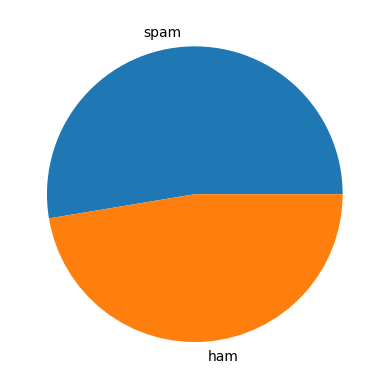

In [17]:
plt.pie(spam_data['label'].value_counts(), labels=['spam','ham'])
plt.show()

In [18]:
import nltk

In [19]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
#number of characters : 
spam_data['num_characters']=spam_data['text'].apply(len)

In [21]:
spam_data.head(3)

,label,text,num_characters
0,1,ounce feather bowl hummingbird opec moment ala...,148
1,1,wulvob get your medircations online qnb ikud v...,808
2,0,computer connection from cnn com wednesday es...,2235


In [22]:
spam_data['num_words']=spam_data['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [23]:
spam_data.head(3)

,label,text,num_characters,num_words
0,1,ounce feather bowl hummingbird opec moment ala...,148,20
1,1,wulvob get your medircations online qnb ikud v...,808,104
2,0,computer connection from cnn com wednesday es...,2235,338


In [24]:
spam_data['num_sentences']=spam_data['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [25]:
spam_data.head(3)

,label,text,num_characters,num_words,num_sentences
0,1,ounce feather bowl hummingbird opec moment ala...,148,20,1
1,1,wulvob get your medircations online qnb ikud v...,808,104,1
2,0,computer connection from cnn com wednesday es...,2235,338,1


In [26]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83446 entries, 0 to 83447
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           83446 non-null  int64 
 1   text            83446 non-null  object
 2   num_characters  83446 non-null  int64 
 3   num_words       83446 non-null  int64 
 4   num_sentences   83446 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 3.8+ MB


In [27]:
spam_data[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,83446.000000,83446.000000,83446.000000
mean,1662.992426,285.034585,7.250210
std,4178.620274,727.054085,34.832721
min,1.000000,1.000000,1.000000
25%,450.000000,80.000000,1.000000
50%,879.000000,154.000000,1.000000
75%,1861.000000,314.000000,5.000000
max,598705.000000,101984.000000,3093.000000


## Data Preprocessing 
    

In [28]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

In [29]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [30]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

# 1. Define these ONCE outside the function
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

def transform_text(text):
    # Lowercase and tokenize
    tokens = nltk.word_tokenize(text.lower())
    
    # Combined filtering and stemming in one pass
    transformed = [
        ps.stem(word) 
        for word in tokens 
        if word.isalnum() and word not in stop_words and word not in punctuation
    ]
    
    return " ".join(transformed)

In [56]:
def transforms_text(text):
    # Lowercase and tokenize
    tokens = nltk.word_tokenize(text.lower())
    
    transformed = []
    for word in tokens:
        # Remove standalone punctuation and stopwords
        if word not in stop_words and word not in punctuation:
            # Check if it has at least one alphanumeric character 
            # (Allows "w1nn3r" but removes "!!!")
            if any(char.isalnum() for char in word):
                transformed.append(ps.stem(word))
    
    return " ".join(transformed)

In [60]:
from collections import Counter

# Get all spam text
all_spam_words = spam_data[spam_data['label']==1]['transformed_text'].str.cat(sep=' ').split()

# See the top 20
print(Counter(all_spam_words).most_common(20))

[('escapenumb', 334201), ('escapelong', 188114), ('com', 29043), ('http', 27851), ('per', 26146), ('pill', 25499), ('price', 24409), ('x', 23825), ('escapenumbermg', 20546), ('compani', 19987), ('one', 16818), ('save', 16468), ('product', 15760), ('item', 15605), ('may', 14669), ('time', 14406), ('get', 14009), ('e', 13958), ('us', 13828), ('pleas', 13373)]


In [31]:
spam_data.text[2]

" computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber escapenumber pm edt in this report next generation toys read brain waves google expands personalization youtube wins webby old fashioned rabbit ears laptop review next generation toys read brain waves a startup company aims to add more realistic elements to video games by using brain wave reading technology to help game developers make gaming more realistic http www cnn com escapenumber tech fun games escapenumber escapenumber mind reading toys ap index html google expands personalization google is stepping up efforts to allow its users to personalize how they search the web http www cnn com escapenumber tech internet escapenumber escapenumber google personalization reut index html youtube wins webby the co founders youtube are among the winners of the annual webby online achievement awards http www cnn com escapenumber tech internet escapenumber escapenumber webby awards ap index html 

In [58]:
transformed_text = transforms_text(" computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber escapenumber pm edt in this report next generation toys read brain waves google expands personalization youtube wins webby old fashioned rabbit ears laptop review next generation toys read brain waves a startup company aims to add more realistic elements to video games by using brain wave reading technology to help game developers make gaming more realistic http www cnn com escapenumber tech fun games escapenumber escapenumber mind reading toys ap index html google expands personalization google is stepping up efforts to allow its users to personalize how they search the web http www cnn com escapenumber tech internet escapenumber escapenumber google personalization reut index html youtube wins webby the co founders youtube are among the winners of the annual webby online achievement awards http www cnn com escapenumber tech internet escapenumber escapenumber webby awards ap index html old fashioned rabbit ears some consumers are spending thousands of dollars on lcd or plasma tvs and hooking them up to escapenumber antennas http www cnn com escapenumber tech ptech escapenumber escapenumber rabbit ear revival ap index html laptop review dell's top shelf xps line has consistently put out distinctive laptops that feature the most advanced components on the market http www cnn com escapenumber tech ptech escapenumber escapenumber dell laptop index html cnn the most trusted name in news you have agreed to receive this email from cnn com as a result of your cnn com preference settings to manage your settings click here http audience cnn com services cnn memberservices member auth jsp url http escapenumbera escapenumberf escapelong cnn com escapelong escapenumberfcnn escapelong escapelong escapenumberfmember profile jsp escapenumberfsource escapenumberdcnn to unsubscribe from the computer connection email list click here http cgi cnn com cgi bin mail clik email ktwarwic speedy uwaterloo ca list computing read our privacy guidelines at http cnn com privacy html cable news network lp lllp one cnn center atlanta georgia escapenumber c escapenumber cable news network a time warner company all rights reserved ")
print(transformed_text)

comput connect cnn com wednesday escapenumb may escapenumb escapenumb escapenumb escapenumb pm edt report next gener toy read brain wave googl expand person youtub win webbi old fashion rabbit ear laptop review next gener toy read brain wave startup compani aim add realist element video game use brain wave read technolog help game develop make game realist http www cnn com escapenumb tech fun game escapenumb escapenumb mind read toy ap index html googl expand person googl step effort allow user person search web http www cnn com escapenumb tech internet escapenumb escapenumb googl person reut index html youtub win webbi co founder youtub among winner annual webbi onlin achiev award http www cnn com escapenumb tech internet escapenumb escapenumb webbi award ap index html old fashion rabbit ear consum spend thousand dollar lcd plasma tv hook escapenumb antenna http www cnn com escapenumb tech ptech escapenumb escapenumb rabbit ear reviv ap index html laptop review dell 's top shelf xp li

In [61]:
spam_data['transformed_text']=spam_data['text'].apply(transforms_text)

In [63]:
spam_data.head(3)

,label,text,num_characters,num_words,num_sentences,transformed_text
0,1,ounce feather bowl hummingbird opec moment ala...,148,20,1,ounc feather bowl hummingbird opec moment alab...
1,1,wulvob get your medircations online qnb ikud v...,808,104,1,wulvob get medirc onlin qnb ikud viagra escape...
2,0,computer connection from cnn com wednesday es...,2235,338,1,comput connect cnn com wednesday escapenumb ma...


In [64]:
from collections import Counter

# Get all spam text
all_spam_words = spam_data[spam_data['label']==1]['transformed_text'].str.cat(sep=' ').split()

# See the top 20
print(Counter(all_spam_words).most_common(20))

[('escapenumb', 334201), ('escapelong', 188114), ('com', 29043), ('http', 27851), ('per', 26146), ('pill', 25499), ('price', 24409), ('x', 23825), ('escapenumbermg', 20546), ('compani', 19987), ("'s", 17235), ('one', 16818), ('save', 16468), ('product', 15760), ('item', 15605), ('may', 14669), ('time', 14406), ('get', 14009), ('e', 13958), ('us', 13828)]


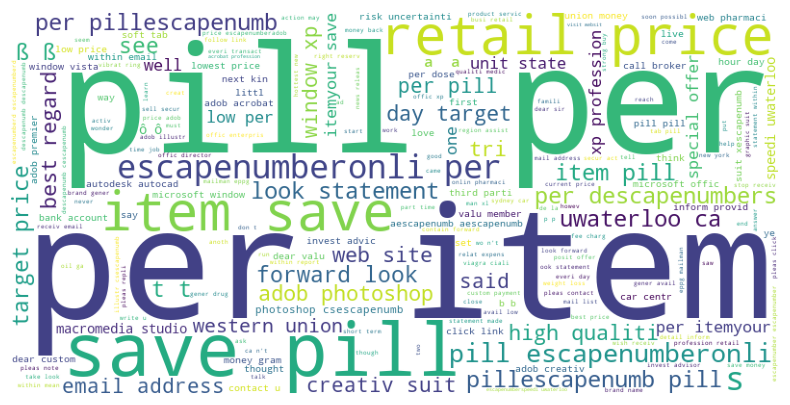

In [65]:
# List of words that are drowning out your actual data
junk_words = {'escapenumb', 'escapelong', 'escapenumbermg', 'x', 'e', 'com', 'http'}

# Filter them out from your spam text
filtered_spam = [word for word in all_spam_words if word not in junk_words]

# Generate the WordCloud again
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(filtered_spam))

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [67]:
spam_data.to_csv(r"D:\Complete_proj\Email_spam\model\data\spam_data1.csv", index=False)

In [66]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83446 entries, 0 to 83447
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   label             83446 non-null  int64 
 1   text              83446 non-null  object
 2   num_characters    83446 non-null  int64 
 3   num_words         83446 non-null  int64 
 4   num_sentences     83446 non-null  int64 
 5   transformed_text  83446 non-null  object
dtypes: int64(4), object(2)
memory usage: 6.5+ MB


In [68]:
spam_data.shape

(83446, 6)

In [69]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83446 entries, 0 to 83447
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   label             83446 non-null  int64 
 1   text              83446 non-null  object
 2   num_characters    83446 non-null  int64 
 3   num_words         83446 non-null  int64 
 4   num_sentences     83446 non-null  int64 
 5   transformed_text  83446 non-null  object
dtypes: int64(4), object(2)
memory usage: 6.5+ MB


In [70]:
spam_data.to_csv(r"D:\Complete_proj\Email_spam\model\data\spam_data2.csv", index=False)